In [43]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit
# from matplotlib.patches import Patch
import pandas as pd

In [44]:
# Data
# FT115, AMAT CVD, SiN
#https://argonnedoe.sharepoint.com/sites/cyndiayu/SitePages/20240102_FT110-and-FT65-CMB-S4-microstrip-testing.aspx?csf=1&web=1&share=ETKMtIqr3LhNtng6JEg6SJMBHhNK3t0wxVpNIvc90q-UOw&e=Sw2Ang&CID=353ffe7f-7b21-454c-a1d6-212bc73e22c9
FT115 = pd.DataFrame(
    {
        "freq": [5.8352,6.1934,6.6050,7.0728,2.9145,3.0942,3.2988,3.5366,],
        "Fd": [0.003039,0.002975,0.003055,0.003059,0.002725,0.002787,0.002860,0.002928,]
    }
)

# FT65, ICPECVD, SiN
FT65 = pd.DataFrame(
    {
        "freq": [2.6163,2.7796,2.9652,3.1746,],
        "Fd": [0.000162,0.000164,0.000174,0.000179,],
    }
)



# SLIM 20, Angst. IBAS, SiN
SLIM20 = pd.DataFrame(
    {
        "freq": [0.6372,1.1786],
        "Fd": [0.001162,0.001062],
    }
)

# SLIM 30, Angst. IBAS, SiN
SLIM30 = pd.DataFrame(
    {
        "freq": [122,133,142,152,161],
        "Fd": [3.3e-3,7.5e-3,6.8e-3,6.2e-3,8.5e-3],
    }
)

# FT156, Anst. IBAS, A-Si
FT156 = pd.DataFrame(
    {
        "freq": [3.90,4.16,4.45,],
        "Fd": [0.000575,0.000586,0.000273],
    }
)

# FT157, Angst. IBAS, A-Si
FT157 = pd.DataFrame(
    {
        "freq": [2.07,2.15,2.29,2.45],
        "Fd": [0.000566,0.000473,0.000344,0.000339],
    }
)

# R2C1, PECVD, SiN
R2C1 = pd.DataFrame(
    {
        "freq": [5.42,5.75,6.13,6.56],
        "Fd": [9.01e-4,9.12e-4,9.2e-4,9.22e-4],
        "S/N ratio": [26./25., 26./25., 26./25., 26./25.],
    }
)

# R3C2, ICPCVD, Less Dense SiN
R3C2 = pd.DataFrame(
    {
        "freq": [5.56, 6.305, 6.755],
        "Fd": [3.49e-3, 3.49e-3, 3.64e-3],
        "S/N ratio": [21./30., 21./30., 21./30.],
    }

)

# R3C1, ICPCVD, More Dense SiN
R3C1 = pd.DataFrame(
    {
        "freq": [5.19, 5.50, 5.87, 6.28],
        "Fd": [4.60e-4, 4.64E-04, 4.72E-04, 4.74E-04],
        "S/N ratio": [30./21., 30./21., 30./21., 30./21.]
    }

)

# R1C3, ICPCVD, Si-rich SiC
R1C3 = pd.DataFrame(
    {
        "freq": [4.66, 4.94, 5.2790],
        "Fd": [0.000164, 0.0001685, 0.00016825], #check calculation below it's an average
        "Fd_mag_up_fast": [1.75e-4, 1.80E-04, 1.78E-04],
        "Fd_mag_down_fast": [1.49e-4, 1.53E-04, 1.55E-04],
        "Fd_mag_up_slow": [1.71e-4, 1.75E-04, 1.75E-04],
        "Fd_mag_down_slow": [1.61e-4, 1.66E-04, 1.65E-04],
    }

)

# R2C3, ICPCVD, High-Q Twin SiC
R2C3 = pd.DataFrame(
    {
        "freq": [5.83],
        "Fd": [0.0001543],
        "C/S ratio": [10./15.]
    }
)

# FT175, IBAS, a-Si:H from Val Novosad
FT175 = pd.DataFrame(
    {
        "freq": [4.56, 5.06, 5.65, 6.18],
        "Fd": [2.08e-4, 1.38e-4, 2.18e-4, 2.12e-4],
    }
)

#everythign below this is not argonne 

marker_map = {"CVD":"o","ICPCVD":"^","IBAS":"x", 'External to ANL':"s"}
sample_list = [FT65,FT115,FT156,FT157,FT175,SLIM20,SLIM30,R2C1, R3C2, R3C1, R1C3, R2C3]
sample_labels = ["FT65 (SiN)","FT115 (SiN)","FT156 (a-Si)","FT157 (a-Si)","FT175 (a-Si:H)","SLIM20 (SiN)","SLIM30 (SiN)","R2C1 (SiN)", "R3C2 (SiN)", "R3C1 (SiN)", "R1C3 (SiC)", "R2C3 (SiC)"]
samp_dep = ['CVD','ICPCVD','IBAS','IBAS','IBAS','IBAS','IBAS','ICPCVD', 'ICPCVD', 'ICPCVD', 'ICPCVD', 'ICPCVD']

# O'Connel et al 0802.2402
OCSNx = pd.DataFrame(
    {
        "freq": [6],
        "Fd": [0.0001],
    }
)

# O'Connel et al 0802.2402
OCasiH = pd.DataFrame(
    {
        "freq": [6],
        "Fd": [0.00002],
    }
)

# Buijtendorp Thesis 
BDasiH = pd.DataFrame(
    {
        "freq": [5],
        "Fd": [0.000038],
    }
)

# Buijtendorp Thesis 
BDasiC = pd.DataFrame(
    {
        "freq": [7.5],
        "Fd": [0.00003],
    }
)
#kopas 2011.10155

kopasage = pd.DataFrame(
    {
        "freq": [7],
        "Fd": [0.0000048],
    }
)

marker_map1 = {"CVD":"s","ICPCVD":"s","IBAS":"s"}
sample_list1 = [OCSNx,OCasiH,BDasiH,BDasiC,kopasage]
sample_labels1 = ["O'Connel (SiN)","O'Connel (A-SI:H)", 'Buijtendorp (a-Si:H)','Buijtendorp (a-Si:C)', 'Kopas a-Ge']
samp_dep1 = ['CVD','ICPCVD','CVD','ICPCVD', 'CVD']

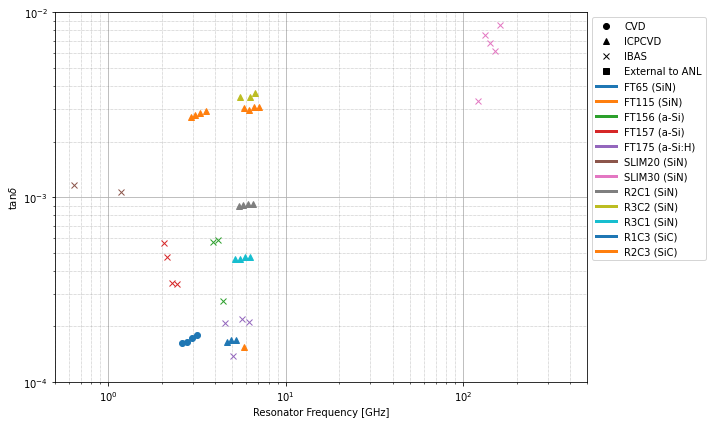

In [45]:
plt.figure(1,figsize=(10,6))

legend_mrks = []
legend_labels = []
for mkidx,mk in enumerate(marker_map.keys()):
    legend_mrks.append(Line2D([0],[0],marker=marker_map[mk],color='k',lw=0))
    legend_labels.append(mk)

lines = []
for sampidx,samp in enumerate(sample_list):
    lines.append(plt.plot(samp['freq'],samp['Fd'],marker_map[samp_dep[sampidx]]))
    legend_mrks.append(Line2D([0],[0],color=lines[sampidx][0].get_color(),lw=3))
    legend_labels.append(sample_labels[sampidx])

ax = plt.gca()
ax.legend(handles=legend_mrks,labels=legend_labels,bbox_to_anchor=(1.0,1.0))
plt.yscale('log')
plt.xscale('log')
plt.ylabel("tan$\delta$")
plt.xlabel("Resonator Frequency [GHz]")
plt.ylim((1e-4,1e-2))
plt.xlim((0.5,500))
plt.grid(True)
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', linewidth='0.5', color='gray')
plt.tight_layout()
plt.savefig('loss_sample_comparison_argonne_only.png',dpi=300)
plt.show()

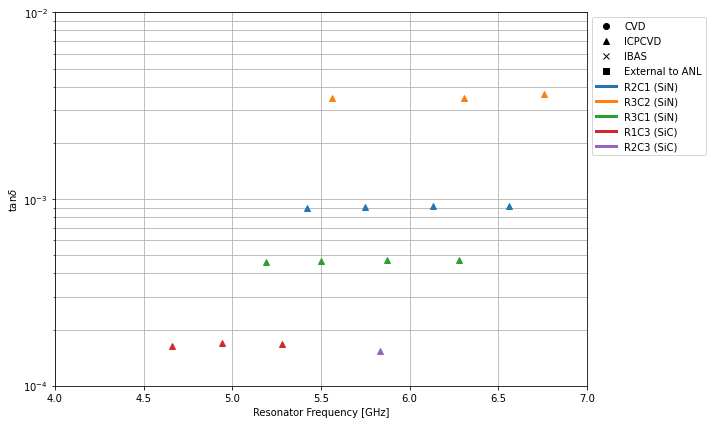

'FT65 (SiN)'
'FT115 (SiN)'
'FT156 (a-Si)'
'FT157 (a-Si)'
'FT175 (a-Si:H)'
'SLIM20 (SiN)'
'SLIM30 (SiN)'
'R2C1 (SiN)'
'R3C2 (SiN)'
'R3C1 (SiN)'
'R1C3 (SiC)'
'R2C3 (SiC)'


In [46]:
LANCE_names = ["R2C1 (SiN)", "R3C2 (SiN)", "R3C1 (SiN)", "R1C3 (SiC)", "R2C3 (SiC)"]

LANCE_list = []
LANCE_labels = []
LANCE_dep = []

for samp, label, dep in zip(sample_list, sample_labels, samp_dep):
    if label in LANCE_names:
        LANCE_list.append(samp)
        LANCE_labels.append(label)
        LANCE_dep.append(dep)
        
plt.figure(1,figsize=(10,6))

legend_mrks = []
legend_labels = []

# marker legend
for mk in marker_map.keys():
    legend_mrks.append(Line2D([0],[0], marker=marker_map[mk], color='k', lw=0))
    legend_labels.append(mk)

lines = []
for i, samp in enumerate(LANCE_list):
    lines.append(
        plt.plot(
            samp['freq'],
            samp['Fd'],
            marker_map[LANCE_dep[i]]
        )
    )
    legend_mrks.append(Line2D([0],[0], color=lines[i][0].get_color(), lw=3))
    legend_labels.append(LANCE_labels[i])

ax = plt.gca()
ax.legend(handles=legend_mrks, labels=legend_labels, bbox_to_anchor=(1.0,1.0))

plt.xscale('linear')
plt.yscale('log')
plt.xlabel("Resonator Frequency [GHz]")
plt.ylabel(r"tan$\delta$")
plt.xlim((4, 7))
plt.ylim((1e-4, 1e-2))
plt.grid(True, which='both')
plt.tight_layout()
plt.savefig('loss_sample_comparison_LANCE_only.png', dpi=300)
plt.show()

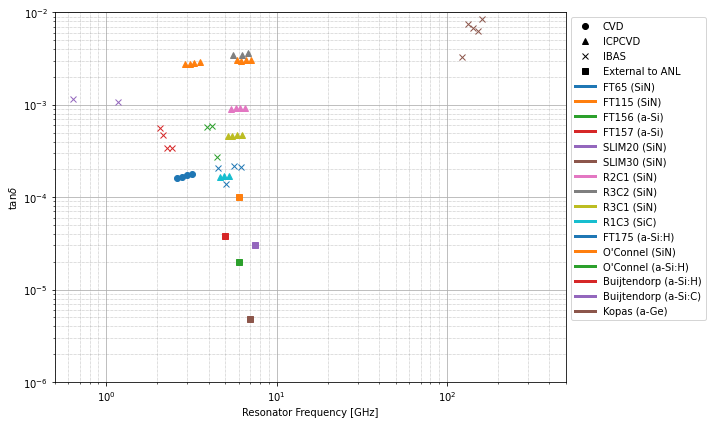

In [30]:
plt.figure(1,figsize=(10,6))

legend_mrks = []
legend_labels = []
for mkidx,mk in enumerate(marker_map.keys()):
    legend_mrks.append(Line2D([0],[0],marker=marker_map[mk],color='k',lw=0))
    legend_labels.append(mk)

lines = []
for sampidx,samp in enumerate(sample_list):
    lines.append(plt.plot(samp['freq'],samp['Fd'],marker_map[samp_dep[sampidx]]))
    legend_mrks.append(Line2D([0],[0],color=lines[sampidx][0].get_color(),lw=3))
    legend_labels.append(sample_labels[sampidx])

lines = []
for sampidx,samp in enumerate(sample_list1):
    lines.append(plt.plot(samp['freq'],samp['Fd'],marker_map1[samp_dep1[sampidx]]))
    legend_mrks.append(Line2D([0],[0],color=lines[sampidx][0].get_color(),lw=3))
    legend_labels.append(sample_labels1[sampidx])

ax = plt.gca()
ax.legend(handles=legend_mrks,labels=legend_labels,bbox_to_anchor=(1.0,1.0))
plt.yscale('log')
plt.xscale('log')
plt.ylabel("tan$\delta$")
plt.xlabel("Resonator Frequency [GHz]")
plt.ylim((1e-6,1e-2))
plt.xlim((0.5,500))
plt.grid(True)
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', linewidth='0.5', color='gray')
plt.tight_layout()
plt.savefig('loss_sample_comparison_full_1.png',dpi=300)
plt.show()

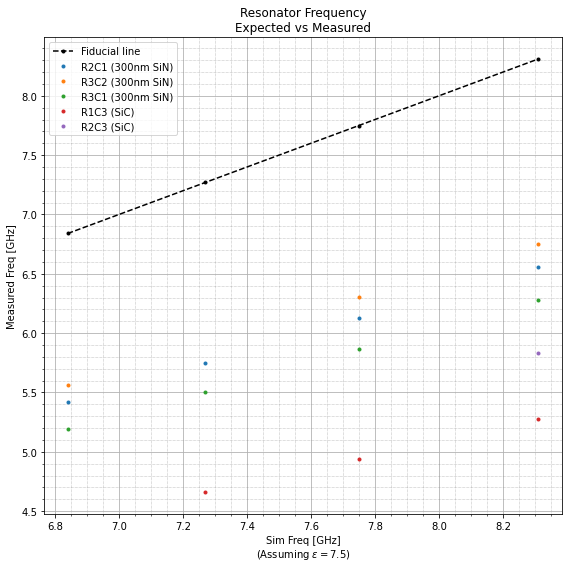

In [31]:
# Compare freq sched
fiducial = np.array([6.84,7.27,7.75,8.31])

plt.figure(2,figsize=(8,8))
plt.plot(fiducial,fiducial,'k.--',label='Fiducial line')
plt.plot(fiducial,R2C1['freq'].iloc[0:4],'.',label='R2C1 (300nm SiN)')
plt.plot([fiducial[0], fiducial[2], fiducial[3]],R3C2['freq'].iloc[0:4],'.',label='R3C2 (300nm SiN)')
plt.plot(fiducial,R3C1['freq'].iloc[0:4],'.',label='R3C1 (300nm SiN)')
plt.plot([fiducial[1], fiducial[2], fiducial[3]], R1C3['freq'].iloc[0:4],'.',label='R1C3 (SiC)')
plt.plot(fiducial[3],R2C3['freq'].iloc[0:4],'.',label='R2C3 (SiC)')


plt.ylabel('Measured Freq [GHz]')
plt.xlabel('Sim Freq [GHz]\n(Assuming $\epsilon=7.5$)')
plt.legend(loc='upper left')
plt.grid(True)
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', linewidth='0.5', color='gray')
plt.title('Resonator Frequency\nExpected vs Measured')
plt.tight_layout()
plt.savefig('sim_comparison_2025XXXX.png',dpi=300)


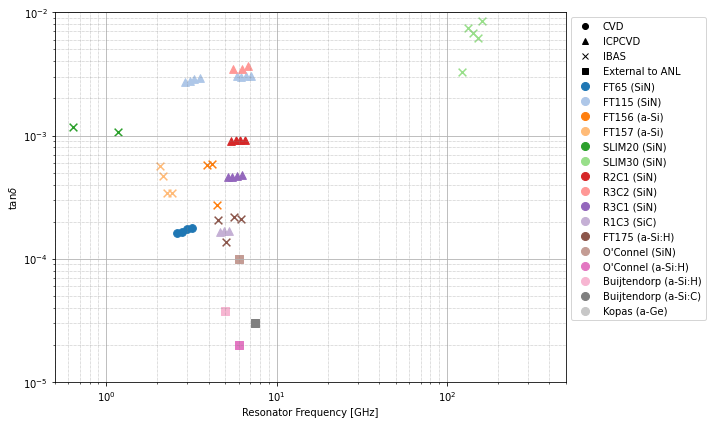

In [32]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import itertools

# --- Choose a large distinct color palette ---
colors = plt.cm.tab20.colors   # 20 distinct colors
color_cycle = itertools.cycle(colors)

plt.figure(figsize=(10,6))

legend_mrks = []
legend_labels = []

# Legend for markers (materials)
for mk in marker_map.keys():
    legend_mrks.append(Line2D([0],[0], marker=marker_map[mk], color='k', lw=0, linestyle='None'))
    legend_labels.append(mk)

# --- First sample set ---
for sampidx, samp in enumerate(sample_list):
    c = next(color_cycle)
    plt.scatter(
        samp['freq'],
        samp['Fd'],
        marker=marker_map[samp_dep[sampidx]],
        color=c,
        s=60
    )
    legend_mrks.append(Line2D([0],[0], marker='o', color=c, lw=0, markersize=8))
    legend_labels.append(sample_labels[sampidx])

# --- Second sample set ---
for sampidx, samp in enumerate(sample_list1):
    c = next(color_cycle)
    plt.scatter(
        samp['freq'],
        samp['Fd'],
        marker=marker_map1[samp_dep1[sampidx]],
        color=c,
        s=60
    )
    legend_mrks.append(Line2D([0],[0], marker='o', color=c, lw=0, markersize=8))
    legend_labels.append(sample_labels1[sampidx])

# --- Formatting ---
ax = plt.gca()
ax.legend(handles=legend_mrks, labels=legend_labels, bbox_to_anchor=(1.0,1.0))
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel("tan$\delta$")
ax.set_xlabel("Resonator Frequency [GHz]")
ax.set_ylim((1e-5,1e-2))
ax.set_xlim((0.5,500))
ax.grid(True)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray')

plt.tight_layout()
plt.savefig('loss_sample_comparison_full_2.png', dpi=300)
plt.show()


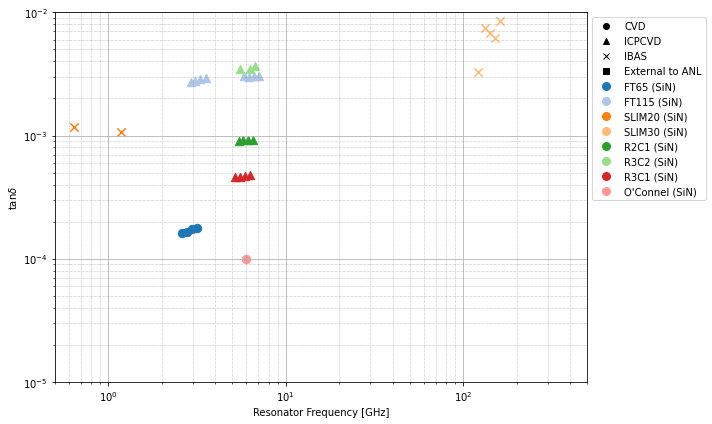

In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import itertools

# --- Choose a large distinct color palette ---
colors = plt.cm.tab20.colors
color_cycle = itertools.cycle(colors)

# --- Filter only SiN samples ---
sin_samples = []
sin_labels = []
sin_deps   = []

for samp, label, dep in zip(sample_list, sample_labels, samp_dep):
    if "SiN" in label:   # only keep SiN entries
        sin_samples.append(samp)
        sin_labels.append(label)
        sin_deps.append(dep)

for samp, label, dep in zip(sample_list1, sample_labels1, samp_dep1):
    if "SiN" in label:   # only keep SiN entries
        sin_samples.append(samp)
        sin_labels.append(label)
        sin_deps.append(dep)

# --- Plot ---
plt.figure(figsize=(10,6))

legend_mrks = []
legend_labels = []

# legend for deposition methods (marker shapes)
for mk in marker_map.keys():
    legend_mrks.append(Line2D([0],[0], marker=marker_map[mk], color='k', lw=0, linestyle='None'))
    legend_labels.append(mk)

# scatter plots for each SiN sample
for samp, label, dep in zip(sin_samples, sin_labels, sin_deps):
    c = next(color_cycle)
    plt.scatter(
        samp['freq'],
        samp['Fd'],
        marker=marker_map.get(dep, 'o'),
        color=c,
        s=70,
        label=label
    )
    legend_mrks.append(Line2D([0],[0], marker='o', color=c, lw=0, markersize=8))
    legend_labels.append(label)

# --- Formatting ---
ax = plt.gca()
ax.legend(handles=legend_mrks, labels=legend_labels, bbox_to_anchor=(1.0,1.0))
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel("tan$\delta$")
ax.set_xlabel("Resonator Frequency [GHz]")
ax.set_ylim((1e-5,1e-2))
ax.set_xlim((0.5,500))
ax.grid(True)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray')

plt.tight_layout()
plt.savefig('loss_SiN_only.png', dpi=300)
plt.show()


$S_{21} (f) = ae^{i \phi} (1 - \frac{Q_r/Q_c}{1 + 2iQ_r(f - f_r)/f_r})$

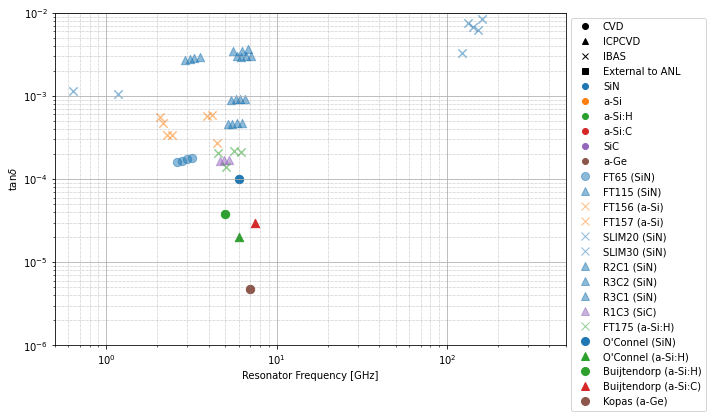

In [33]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Material colors ---
material_colors = {
    "SiN": "tab:blue",
    "a-Si": "tab:orange",
    "a-Si:H": "tab:green",
    "a-Si:C": "tab:red",
    "SiC": "tab:purple",
    "a-Ge": "tab:brown",
}

# --- Deposition markers ---
marker_map = {"CVD": "o", "ICPCVD": "^", "IBAS": "x", "External to ANL": "s"}

# --- Argonne samples ---
sample_list = [FT65,FT115,FT156,FT157,SLIM20,SLIM30,R2C1,R3C2,R3C1,R1C3,FT175]
sample_labels = ["FT65 (SiN)","FT115 (SiN)","FT156 (a-Si)","FT157 (a-Si)",
                 "SLIM20 (SiN)","SLIM30 (SiN)","R2C1 (SiN)","R3C2 (SiN)",
                 "R3C1 (SiN)","R1C3 (SiC)","FT175 (a-Si:H)"]
samp_dep = ['CVD','ICPCVD','IBAS','IBAS','IBAS','IBAS',
            'ICPCVD','ICPCVD','ICPCVD','ICPCVD','IBAS']

# --- Outside Argonne samples ---
sample_list1 = [OCSNx,OCasiH,BDasiH,BDasiC,kopasage]
sample_labels1 = ["O'Connel (SiN)","O'Connel (a-Si:H)",
                  "Buijtendorp (a-Si:H)","Buijtendorp (a-Si:C)", "Kopas (a-Ge)"]
samp_dep1 = ['CVD','ICPCVD','CVD','ICPCVD','CVD']

# --- Helper: get material from label ---
def get_material(label):
    if "SiN" in label: return "SiN"
    if "a-Si:H" in label: return "a-Si:H"
    if "a-Si:C" in label: return "a-Si:C"
    if "a-Si" in label: return "a-Si"
    if "SiC" in label: return "SiC"
    if "a-Ge" in label: return "a-Ge"
    return "unknown"

plt.figure(figsize=(10,6))

# --- Legend handles ---
legend_mrks = []
legend_labels = []

# 1. Deposition method legend
for mk, mshape in marker_map.items():
    legend_mrks.append(Line2D([0],[0], marker=mshape, color='k', lw=0, linestyle='None'))
    legend_labels.append(mk)

# 2. Material legend
for mat, col in material_colors.items():
    legend_mrks.append(Line2D([0],[0], marker='o', color=col, lw=0, linestyle='None'))
    legend_labels.append(mat)

# 3. Sample entries
# Argonne samples (alpha=0.5)
for samp, label, dep in zip(sample_list, sample_labels, samp_dep):
    mat = get_material(label)
    plt.scatter(samp['freq'], samp['Fd'],
                marker=marker_map[dep],
                color=material_colors[mat],
                alpha=0.5, s=70)
    legend_mrks.append(Line2D([0],[0],
                              marker=marker_map[dep],
                              color=material_colors[mat],
                              lw=0, linestyle='None',
                              alpha=0.5, markersize=8))
    legend_labels.append(label)

# Non-Argonne samples (alpha=1.0)
for samp, label, dep in zip(sample_list1, sample_labels1, samp_dep1):
    mat = get_material(label)
    plt.scatter(samp['freq'], samp['Fd'],
                marker=marker_map.get(dep, 'o'),
                color=material_colors[mat],
                alpha=1.0, s=70)
    legend_mrks.append(Line2D([0],[0],
                              marker=marker_map.get(dep,'o'),
                              color=material_colors[mat],
                              lw=0, linestyle='None',
                              alpha=1.0, markersize=8))
    legend_labels.append(label)

# --- Formatting ---
ax = plt.gca()
ax.legend(handles=legend_mrks, labels=legend_labels,
          bbox_to_anchor=(1.0,1.0), loc="upper left")
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel("tan$\delta$")
ax.set_xlabel("Resonator Frequency [GHz]")
ax.set_ylim((1e-6,1e-2))
ax.set_xlim((0.5,500))
ax.grid(True)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray')

plt.tight_layout()
plt.savefig('loss_sample_comparison_full_material.png', dpi=300)
plt.show()


Loss Tangent at the max S/N Ratio of 49/2 using the Exp Fit would be  4.359e-31
Loss Tangent at the max S/N Ratio of 49/2 using the Power Fit would be  3.784e-08


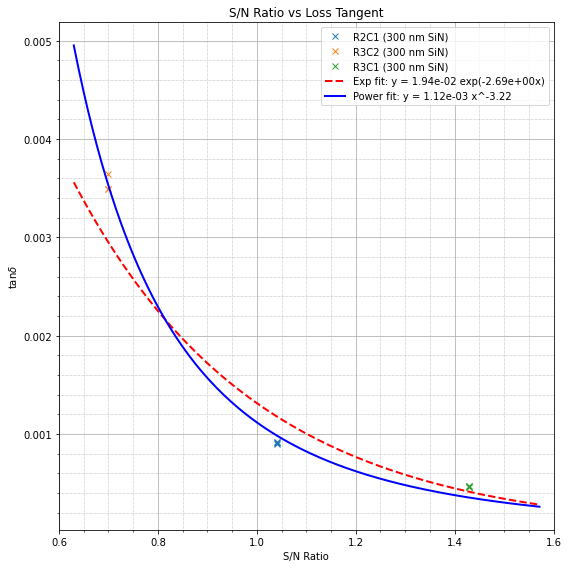

In [22]:
# Compare S/N ratio to loss tangent

plt.figure(2,figsize=(8,8))
plt.plot(R2C1['S/N ratio'].iloc[0:4], R2C1['Fd'].iloc[0:4], 'x', label='R2C1 (300 nm SiN)')
plt.plot(R3C2['S/N ratio'].iloc[0:4], R3C2['Fd'].iloc[0:4], 'x', label='R3C2 (300 nm SiN)')
plt.plot(R3C1['S/N ratio'].iloc[0:4], R3C1['Fd'].iloc[0:4], 'x', label='R3C1 (300 nm SiN)')

x = np.concatenate([R2C1['S/N ratio'].iloc[0:4].to_numpy(), R3C2['S/N ratio'].iloc[0:4].to_numpy(), R3C1['S/N ratio'].iloc[0:4].to_numpy()])
y = np.concatenate([R2C1['Fd'].iloc[0:4].to_numpy(), R3C2['Fd'].iloc[0:4].to_numpy(), R3C1['Fd'].iloc[0:4].to_numpy()])


x_fit = np.linspace(min(x)*0.9, max(x)*1.1, 200)

# --- Exponential fit ---
coeffs_exp = np.polyfit(x, np.log(y), 1)
B_exp, lnA_exp = coeffs_exp
A_exp = np.exp(lnA_exp)
y_fit_exp = A_exp * np.exp(B_exp * x_fit)
plt.plot(x_fit, y_fit_exp, 'r--', lw=2, label=f'Exp fit: y = {A_exp:.2e} exp({B_exp:.2e}x)')

# --- Improved Power law fit using curve_fit ---
def power_law(x, A, B):
    return A * x**B

# Initial guess from log-log linearization
B_init, lnA_init = np.polyfit(np.log(x), np.log(y), 1)
A_init = np.exp(lnA_init)

params, cov = curve_fit(power_law, x, y, p0=[A_init, B_init])
A_pow, B_pow = params
y_fit_pow = power_law(x_fit, A_pow, B_pow)

plt.plot(x_fit, y_fit_pow, 'b-', lw=2, label=f'Power fit: y = {A_pow:.2e} x^{B_pow:.2f}')

#best fit equation: y = 0.0002998166 + (0.3094589 - 0.0002998166)/(1 + (x/0.2377285)^4.21118)
x_best_fit = np.linspace(0.7, 25., 1000)
y_best_fit = 0.0002998166 + (0.3094589 - 0.0002998166)/(1 + (x_best_fit/0.2377285)**4.21118)

#plt.plot(x_best_fit, y_best_fit, 'g-.', lw=2, label=f'Best fit')

plt.xlabel('S/N Ratio')
plt.ylabel("tan$\delta$")
plt.xlim([0.6, 1.6])
plt.legend(loc='upper right')
plt.grid(True)
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', linewidth='0.5', color='gray')
plt.title('S/N Ratio vs Loss Tangent')
plt.tight_layout()
plt.savefig('SN_Ratio_compare_exponential_fit.png',dpi=300)




def loss_tangent_best_fit(x):
    """
    Compute y = tan(delta) for a given x using the best fit formula.
    """
    return 0.0002998166 + (0.3094589 - 0.0002998166) / (1 + (x / 0.2377285)**4.21118)


def loss_tangent_exp_fit(x):
    """
    Compute y = tan(delta) for a given x using the exp fit formula.
    """
    return A_exp * np.exp(B_exp * x)

def loss_tangent_power_fit(x):
    """
    Compute y = tan(delta) for a given x using the power fit formula.
    """
    return power_law(x, A_pow, B_pow)


#loss_at_max_SN_ratio_best_fit = loss_tangent_best_fit(24.5)
loss_at_max_SN_ratio_exp_fit = loss_tangent_exp_fit(24.5)
loss_at_max_SN_ratio_power_fit = loss_tangent_power_fit(24.5)

#print("Loss Tangent at the max S/N Ratio of 49/2 using the Best Fit would be ", np.format_float_scientific(loss_at_max_SN_ratio_best_fit, precision=3))
print("Loss Tangent at the max S/N Ratio of 49/2 using the Exp Fit would be ", np.format_float_scientific(loss_at_max_SN_ratio_exp_fit, precision=3))
print("Loss Tangent at the max S/N Ratio of 49/2 using the Power Fit would be ", np.format_float_scientific(loss_at_max_SN_ratio_power_fit, precision=3))


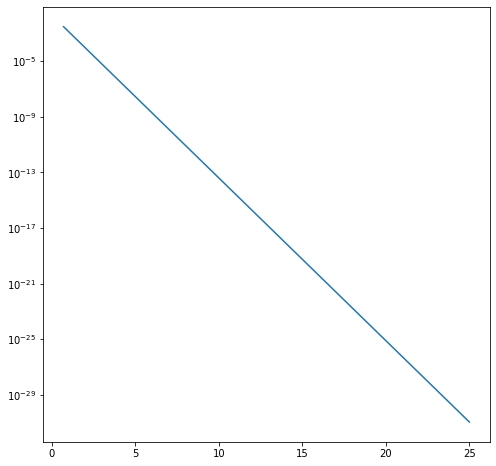

In [104]:
x_test = np.linspace(0.7, 25., 1000)

y_test_exp = A_exp * np.exp(B_exp * x_test)

plt.figure(2,figsize=(8,8))
plt.plot(x_test, y_test_exp)
plt.yscale('log')

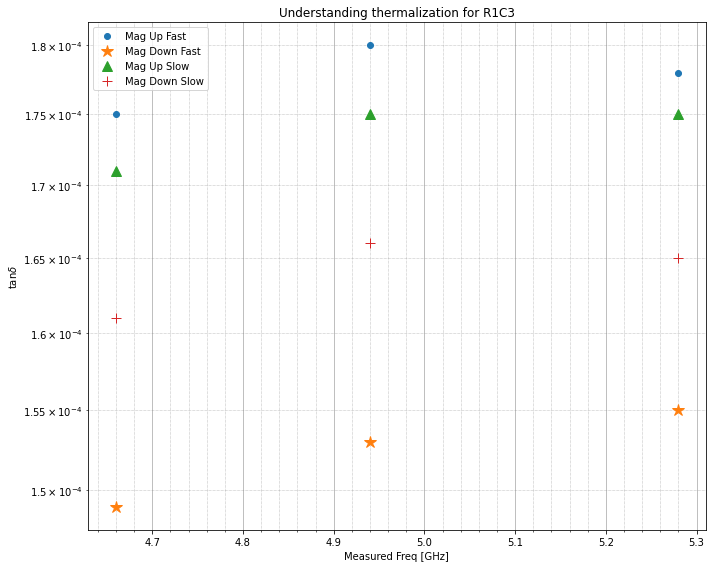

In [23]:
#Understanding thermalization with R1C3

#plt.plot(fiducial,R3C1['freq'].iloc[0:4],'.',label='R3C1 (300nm SiN)')

plt.figure(figsize=(10, 8))
plt.plot(R1C3['freq'].iloc[0:4], R1C3['Fd_mag_up_fast'].iloc[0:4], '.', markersize=12, label='Mag Up Fast')
plt.plot(R1C3['freq'].iloc[0:4], R1C3['Fd_mag_down_fast'].iloc[0:4], '*', markersize=12, label='Mag Down Fast')
plt.plot(R1C3['freq'].iloc[0:4], R1C3['Fd_mag_up_slow'].iloc[0:4], '^', markersize=10, label='Mag Up Slow')
plt.plot(R1C3['freq'].iloc[0:4], R1C3['Fd_mag_down_slow'].iloc[0:4], '+', markersize=10, label='Mag Down Slow')


plt.ylabel("tan$\delta$")
plt.xlabel('Measured Freq [GHz]')
plt.yscale('log')
plt.legend(loc='upper left')
plt.grid(True)
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', linewidth='0.5', color='gray')
plt.title('Understanding thermalization for R1C3')
plt.tight_layout()
plt.savefig('R1C3_thermalization_comparison.png',dpi=300)

In [53]:
R1C3_res0 = np.average([R1C3['Fd_mag_up_fast'][0], R1C3['Fd_mag_down_fast'][0], R1C3['Fd_mag_up_slow'][0], R1C3['Fd_mag_down_slow'][0]])
R1C3_res1 = np.average([R1C3['Fd_mag_up_fast'][1], R1C3['Fd_mag_down_fast'][1], R1C3['Fd_mag_up_slow'][1], R1C3['Fd_mag_down_slow'][1]])
R1C3_res2 = np.average([R1C3['Fd_mag_up_fast'][2], R1C3['Fd_mag_down_fast'][2], R1C3['Fd_mag_up_slow'][2], R1C3['Fd_mag_down_slow'][2]])

R1C3 = np.array([R1C3_res0, R1C3_res1, R1C3_res2])
np.average(R1C3)

0.00016691666666666667